# Beer Recommender — Load Saved Models & Evaluate (v3)
### Zero retraining. Loads weights from Drive, runs all evaluations with fixed cold-start.

**What this notebook does (no training):**
1. Data loading + preprocessing (needed to reconstruct `user2idx`, `item2idx`, feature arrays)
2. Load saved model weights from Google Drive
3. Rating-prediction evaluation (MF, HybridNeuMF)
4. Ranking evaluation (MF, HybridNeuMF, MetadataSASRec)
5. Cold-item evaluation
6. Cold-user evaluation — **fixed with Bayesian Hybrid + MMR diversity**
7. Demo recommendations with rarity penalty

**Estimated runtime: ~10–15 min** (dominated by data loading, not training)


## 1. Imports & Device

In [1]:
import os, ast, copy, math, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 30)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    torch.cuda.empty_cache()
    torch.cuda.manual_seed_all(SEED)
    print(f'GPU: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: Apple MPS')
else:
    DEVICE = torch.device('cpu')
    print('Device: CPU')
print('Active device:', DEVICE)


GPU: Tesla T4
Active device: cuda


## 2. Data Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE_PATH    = Path('/content/drive/MyDrive/RCCSYS')
SOURCE_FILES = {
    'beeradvocate': BASE_PATH / 'beeradvocate.json',
    'ratebeer':     BASE_PATH / 'ratebeer.json',
}
SAVE_DIR = '/content/drive/MyDrive/Beer_Recommender_Models'

def load_dict_per_line(filepath):
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(ast.literal_eval(line))
    return pd.DataFrame(records)

t0 = time.time()
beer_advocate = load_dict_per_line(SOURCE_FILES['beeradvocate'])
rate_beer     = load_dict_per_line(SOURCE_FILES['ratebeer'])
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'BeerAdvocate: {beer_advocate.shape}  |  RateBeer: {rate_beer.shape}')


Mounted at /content/drive
Loaded in 265.4s
BeerAdvocate: (1586615, 13)  |  RateBeer: (2924164, 13)


## 3. Preprocessing, K-Core & Feature Engineering

In [3]:
RATING_COLS = ['review/appearance', 'review/aroma', 'review/palate',
               'review/taste', 'review/overall']

def parse_rating(val):
    try:
        s = str(val)
        if '/' in s:
            num, denom = s.split('/')
            return float(num) / float(denom)
        return float(s) / 5.0
    except (ValueError, TypeError):
        return np.nan

for col in RATING_COLS:
    beer_advocate[col] = beer_advocate[col].apply(parse_rating)
    rate_beer[col]     = rate_beer[col].apply(parse_rating)

for df_ in (beer_advocate, rate_beer):
    df_['beer/ABV']    = pd.to_numeric(df_['beer/ABV'],    errors='coerce')
    df_['review/time'] = pd.to_numeric(df_['review/time'], errors='coerce')

beer_advocate['source'] = 'beeradvocate'
rate_beer['source']     = 'ratebeer'
df = pd.concat([beer_advocate, rate_beer], ignore_index=True)
df['item_id'] = df['source'] + '_' + df['beer/beerId'].astype(str)

# Name lookup for recommendations
item_name_lookup = (
    df.dropna(subset=['item_id', 'beer/name'])
    .drop_duplicates('item_id')[['item_id','beer/name','beer/style','beer/ABV','source']]
    .set_index('item_id')
)

before = len(df)
df = df.dropna(subset=['review/profileName', 'item_id', 'review/overall']).copy()
df = df.drop_duplicates(subset=['review/profileName', 'item_id'], keep='first').copy()
print(f'After null/dedup: {before:,} → {len(df):,}')

MIN_REVIEWS = 10
for iteration in range(5):
    prev = len(df)
    uc = df['review/profileName'].value_counts()
    ic = df['item_id'].value_counts()
    df = df[df['review/profileName'].isin(uc[uc >= MIN_REVIEWS].index)]
    df = df[df['item_id'].isin(ic[ic >= MIN_REVIEWS].index)]
    df = df.reset_index(drop=True)
    print(f'K-core iter {iteration+1}: {prev:,} → {len(df):,}')
    if len(df) == prev:
        break
print(f'Final: {len(df):,} rows | {df["review/profileName"].nunique():,} users | {df["item_id"].nunique():,} items')


After null/dedup: 4,510,779 → 4,427,040
K-core iter 1: 4,427,040 → 3,955,615
K-core iter 2: 3,955,615 → 3,948,441
K-core iter 3: 3,948,441 → 3,947,948
K-core iter 4: 3,947,948 → 3,947,930
K-core iter 5: 3,947,930 → 3,947,930
Final: 3,947,930 rows | 19,144 users | 48,104 items


In [4]:
ASPECT_COLS = ['review/aroma', 'review/appearance', 'review/palate', 'review/taste']

beer_meta = df.groupby('item_id').agg(
    style      = ('beer/style',       'first'),
    abv        = ('beer/ABV',         'first'),
    aroma      = ('review/aroma',     'mean'),
    appearance = ('review/appearance','mean'),
    palate     = ('review/palate',    'mean'),
    taste      = ('review/taste',     'mean'),
    n_reviews  = ('review/overall',   'count'),
    mean_rating= ('review/overall',   'mean'),
).reset_index()

beer_meta['avg_aspect'] = beer_meta[['aroma','appearance','palate','taste']].mean(axis=1)
beer_meta['aspect_var'] = beer_meta[['aroma','appearance','palate','taste']].var(axis=1).fillna(0.0)

le_style = LabelEncoder()
beer_meta['style_idx'] = le_style.fit_transform(beer_meta['style'].fillna('Unknown'))
n_styles = int(beer_meta['style_idx'].max()) + 1

abv_mean = beer_meta['abv'].mean(skipna=True)
beer_meta['abv_norm'] = (beer_meta['abv'].fillna(abv_mean) / 15.0).clip(0.0, 1.0)

def abv_to_tier(abv):
    if pd.isna(abv): return 1
    if abv < 4.5:    return 0
    elif abv < 7.0:  return 1
    elif abv < 10.0: return 2
    else:            return 3
N_ABV_TIERS = 4
beer_meta['abv_tier'] = beer_meta['abv'].apply(abv_to_tier)

style_prior = (
    beer_meta.groupby('style')['mean_rating']
    .agg(count='count', mean='mean')
    .assign(prior=lambda x: (x['count']*x['mean'] + 25*x['mean'].mean()) / (x['count']+25))
    ['prior'].to_dict()
)
global_prior = float(beer_meta['mean_rating'].mean())
beer_meta['style_pop_prior'] = beer_meta['style'].map(style_prior).fillna(global_prior)

beer_meta['log_count'] = np.log1p(beer_meta['n_reviews'])
log_count_max = float(beer_meta['log_count'].max())
beer_meta['log_count_norm'] = (beer_meta['log_count'] / log_count_max).clip(0.0, 1.0)

beer_feature_dict = beer_meta.set_index('item_id').to_dict('index')
GLOBAL_PRIOR = global_prior

# Merge features into df
for col in ['style_idx','abv_norm','abv_tier','avg_aspect','aspect_var','style_pop_prior','log_count_norm']:
    df[col] = df['item_id'].map(beer_meta.set_index('item_id')[col])
df['style_idx'] = df['style_idx'].fillna(0).astype(int)
df['abv_tier']  = df['abv_tier'].fillna(1).astype(int)
for col in ['abv_norm','avg_aspect','aspect_var','style_pop_prior','log_count_norm']:
    df[col] = df[col].fillna(0.0).astype(float)

print(f'Feature engineering done. n_styles={n_styles}')
print(beer_meta[['style','abv_norm','avg_aspect','style_pop_prior']].head(3))


Feature engineering done. n_styles=179
         style  abv_norm  avg_aspect  style_pop_prior
0       Dubbel  0.466667    0.760668         0.738086
1  Pumpkin Ale  0.380000    0.623151         0.724719
2         Bock  0.383333    0.758989         0.716331


## 4. Chronological Split & ID Mappings

In [5]:
df_sorted = df.sort_values(['review/profileName','review/time']).reset_index(drop=True)
train_parts, val_parts, test_parts = [], [], []

for _, g in df_sorted.groupby('review/profileName', sort=False):
    n = len(g)
    if n <= 5:
        train_parts.append(g); continue
    if n < 10:
        train_parts.append(g); continue
    n_test  = max(1, int(round(0.1 * n)))
    n_val   = max(1, int(round(0.1 * n)))
    n_train = n - n_val - n_test
    if n_train < 1:
        train_parts.append(g); continue
    train_parts.append(g.iloc[:n_train])
    val_parts.append(  g.iloc[n_train:n_train + n_val])
    test_parts.append( g.iloc[n_train + n_val:])

train_df = pd.concat(train_parts, ignore_index=True)
val_df   = pd.concat(val_parts,   ignore_index=True) if val_parts   else pd.DataFrame(columns=df.columns)
test_df  = pd.concat(test_parts,  ignore_index=True) if test_parts  else pd.DataFrame(columns=df.columns)

n_total = len(df)
print(f'Train: {len(train_df):,}  ({100*len(train_df)/n_total:.1f}%)')
print(f'Val:   {len(val_df):,}  ({100*len(val_df)/n_total:.1f}%)')
print(f'Test:  {len(test_df):,}  ({100*len(test_df)/n_total:.1f}%)')

train_users = sorted(train_df['review/profileName'].unique())
train_items = sorted(train_df['item_id'].unique())
user2idx = {u: i for i, u in enumerate(train_users)}
item2idx = {it: i for i, it in enumerate(train_items)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}
n_users = len(user2idx)
n_items = len(item2idx)

for frame in (val_df, test_df):
    mask = frame['review/profileName'].isin(user2idx) & frame['item_id'].isin(item2idx)
    frame.drop(frame.index[~mask], inplace=True)
    frame.reset_index(drop=True, inplace=True)

for frame in (train_df, val_df, test_df):
    frame['user_idx'] = frame['review/profileName'].map(user2idx)
    frame['item_idx'] = frame['item_id'].map(item2idx)

global_mean    = float(train_df['review/overall'].mean())
n_styles_train = n_styles
print(f'n_users={n_users:,}  n_items={n_items:,}  n_styles={n_styles_train}')
print(f'Global mean: {global_mean:.4f}')


Train: 3,158,714  (80.0%)
Val:   394,608  (10.0%)
Test:  394,608  (10.0%)
n_users=19,144  n_items=47,795  n_styles=179
Global mean: 0.6970


## 5. Item Feature Arrays & Baselines

In [6]:
# Pre-build 1-indexed item arrays (index 0 = padding)
item_style_arr  = np.zeros(n_items+1, dtype=np.int64)
item_abv_arr    = np.zeros(n_items+1, dtype=np.float32)
item_aspect_arr = np.zeros((n_items+1, 4), dtype=np.float32)
item_tier_arr   = np.ones( n_items+1, dtype=np.int64)
item_var_arr    = np.zeros(n_items+1, dtype=np.float32)

for it, idx in item2idx.items():
    feat = beer_feature_dict.get(it, {})
    item_style_arr[idx+1]  = int(feat.get('style_idx', 0))
    item_abv_arr[idx+1]    = float(feat.get('abv_norm', 0.5))
    item_aspect_arr[idx+1] = [
        float(feat.get('aroma', 0.7)),
        float(feat.get('appearance', 0.7)),
        float(feat.get('palate', 0.7)),
        float(feat.get('taste', 0.7)),
    ]
    item_tier_arr[idx+1]   = int(feat.get('abv_tier', 1))
    item_var_arr[idx+1]    = float(feat.get('aspect_var', 0.0))

# Bayesian popularity stats (needed for cold-start and rarity penalty)
C, m = global_mean, 25
item_stats = train_df.groupby('item_id')['review/overall'].agg(count='count', mean='mean')
item_stats['score'] = (item_stats['count']*item_stats['mean'] + m*C) / (item_stats['count']+m)
item_score_lu  = item_stats['score'].to_dict()
user_bias_lu   = (train_df.groupby('review/profileName')['review/overall'].mean() - C).to_dict()
item_bias_lu   = (train_df.groupby('item_id')['review/overall'].mean() - C).to_dict()

# Sequential user sequences for SASRec
MAX_SEQ_LEN = 50
PAD_TOKEN   = 0
user_train_seqs = {}
for user, grp in train_df.sort_values('review/time').groupby('review/profileName'):
    u_idx = user2idx[user]
    user_train_seqs[u_idx] = [item2idx[it]+1 for it in grp['item_id'] if it in item2idx]

print('Item arrays built.')
print(f'item_style_arr shape: {item_style_arr.shape}')
print(f'user_train_seqs: {len(user_train_seqs):,} users')


Item arrays built.
item_style_arr shape: (47796,)
user_train_seqs: 19,144 users


## 6. Evaluation Utilities

In [7]:
criterion = nn.MSELoss()
K_LIST = [5, 10, 20]
RELEVANCE_THRESHOLD = 0.7

@torch.no_grad()
def eval_rmse(loader, model, is_hybrid=False):
    model.eval()
    se, n = 0.0, 0
    for batch in loader:
        if is_hybrid:
            u, i, s, a, asp, tier, var, r = [x.to(DEVICE, non_blocking=True) for x in batch]
            p = model(u, i, s, a, asp, tier, var)
        else:
            u, i, r = [x.to(DEVICE, non_blocking=True) for x in batch]
            p = model(u, i)
        se += ((p - r)**2).sum().item(); n += len(r)
    return float(np.sqrt(se / n))

@torch.no_grad()
def eval_mae(loader, model, is_hybrid=False):
    model.eval()
    ae, n = 0.0, 0
    for batch in loader:
        if is_hybrid:
            u, i, s, a, asp, tier, var, r = [x.to(DEVICE, non_blocking=True) for x in batch]
            p = model(u, i, s, a, asp, tier, var)
        else:
            u, i, r = [x.to(DEVICE, non_blocking=True) for x in batch]
            p = model(u, i)
        ae += torch.abs(p - r).sum().item(); n += len(r)
    return float(ae / n)

def ndcg_at_k(recs, rel, k):
    dcg  = sum(1.0/math.log2(r+2) for r,it in enumerate(recs[:k]) if it in rel)
    idcg = sum(1.0/math.log2(r+2) for r in range(min(k,len(rel))))
    return dcg/idcg if idcg else 0.0
def precision_at_k(recs, rel, k): return len(set(recs[:k]) & rel)/k if k else 0.0
def recall_at_k(recs, rel, k):    return len(set(recs[:k]) & rel)/len(rel) if rel else 0.0
def hit_rate_at_k(recs, rel, k):  return 1.0 if set(recs[:k]) & rel else 0.0
def arr_rmse(y,p): return float(np.sqrt(np.mean((np.array(y)-np.array(p))**2)))
def arr_mae(y,p):  return float(np.mean(np.abs(np.array(y)-np.array(p))))

print('Evaluation utilities defined.')


Evaluation utilities defined.


## 7. Model Architecture Definitions

In [8]:
# ── MatrixFactorization ────────────────────────────────────────────────────────
class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, n_factors=32, global_mean=0.5, dropout=0.3):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.item_factors = nn.Embedding(n_items, n_factors)
        self.user_bias    = nn.Embedding(n_users, 1)
        self.item_bias    = nn.Embedding(n_items, 1)
        self.dropout      = nn.Dropout(dropout)
        self.global_mean  = nn.Parameter(torch.tensor([global_mean]), requires_grad=False)
        nn.init.normal_(self.user_factors.weight, std=0.01)
        nn.init.normal_(self.item_factors.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)
    def forward(self, users, items):
        u = self.dropout(self.user_factors(users))
        v = self.dropout(self.item_factors(items))
        return torch.clamp(self.global_mean + (u*v).sum(dim=1) +
                           self.user_bias(users).squeeze(-1) +
                           self.item_bias(items).squeeze(-1), 0.0, 1.0)
    def l2_reg(self, users, items, embed_reg=1e-5, bias_reg=5e-7):
        uf=self.user_factors(users); it=self.item_factors(items)
        ub=self.user_bias(users);    ib=self.item_bias(items)
        return embed_reg*(uf.pow(2).sum()+it.pow(2).sum())/len(users) +                bias_reg*(ub.pow(2).sum()+ib.pow(2).sum())/len(users)

# ── HybridNeuMF ───────────────────────────────────────────────────────────────
class HybridNeuMF(nn.Module):
    def __init__(self, n_users, n_items, n_styles, n_abv_tiers=4,
                 gmf_factors=32, mlp_factors=32, style_dim=16, tier_dim=4,
                 hidden_sizes=None, dropout_gmf=0.1, dropout_mlp=0.3):
        super().__init__()
        if hidden_sizes is None: hidden_sizes = [128, 64, 32, 16]
        self.gmf_user  = nn.Embedding(n_users, gmf_factors)
        self.gmf_item  = nn.Embedding(n_items, gmf_factors)
        self.drop_gmf  = nn.Dropout(dropout_gmf)
        self.mlp_user  = nn.Embedding(n_users, mlp_factors)
        self.mlp_item  = nn.Embedding(n_items, mlp_factors)
        self.style_emb = nn.Embedding(n_styles+1, style_dim, padding_idx=0)
        self.tier_emb  = nn.Embedding(n_abv_tiers, tier_dim)
        mlp_in = mlp_factors*2 + style_dim + tier_dim + 3
        layers, in_d = [], mlp_in
        for h in hidden_sizes:
            layers += [nn.Linear(in_d,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout_mlp)]
            in_d = h
        self.mlp    = nn.Sequential(*layers)
        self.mlp_out = hidden_sizes[-1]
        self.fusion  = nn.Linear(gmf_factors + self.mlp_out, 1, bias=False)
        for emb in [self.gmf_user,self.gmf_item,self.mlp_user,self.mlp_item,self.tier_emb]:
            nn.init.normal_(emb.weight, std=0.01)
        nn.init.normal_(self.style_emb.weight, std=0.01)
        for m in self.mlp.modules():
            if isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
        nn.init.constant_(self.fusion.weight, 0.5)
    def forward(self, users, items, styles, abv, avg_aspect, abv_tier, aspect_var):
        gmf_out = self.drop_gmf(self.gmf_user(users)) * self.drop_gmf(self.gmf_item(items))
        inp = torch.cat([self.mlp_user(users), self.mlp_item(items),
                         self.style_emb(styles), self.tier_emb(abv_tier),
                         abv.unsqueeze(1), avg_aspect.unsqueeze(1), aspect_var.unsqueeze(1)], dim=1)
        logit = self.fusion(torch.cat([gmf_out, self.mlp(inp)], dim=1)).squeeze(-1)
        return torch.clamp(torch.sigmoid(logit), 0.0, 1.0)
    def l2_reg(self, users, items, embed_reg=1e-5, bias_reg=5e-7):
        uf=self.gmf_user(users); vf=self.gmf_item(items)
        um=self.mlp_user(users); vm=self.mlp_item(items)
        return embed_reg*(uf.pow(2).sum()+vf.pow(2).sum()+um.pow(2).sum()+vm.pow(2).sum())/len(users)

# ── MetadataSASRec ────────────────────────────────────────────────────────────
class PointWiseFeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model,d_model*4), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(d_model*4,d_model), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)

class MetadataSASRec(nn.Module):
    def __init__(self, n_items, n_styles, d_model=64, num_heads=2, num_blocks=2,
                 max_seq_len=50, dropout=0.2, style_dim=16, abv_dim=8, aspect_dim=8):
        super().__init__()
        self.d_model=d_model; self.max_seq_len=max_seq_len
        item_emb_dim = d_model - style_dim - abv_dim - aspect_dim
        self.item_emb   = nn.Embedding(n_items+1, item_emb_dim, padding_idx=0)
        self.style_emb  = nn.Embedding(n_styles+1, style_dim,   padding_idx=0)
        self.abv_proj   = nn.Linear(1, abv_dim,    bias=False)
        self.asp_proj   = nn.Linear(4, aspect_dim, bias=False)
        self.input_proj = nn.Linear(d_model, d_model)
        self.pos_emb    = nn.Embedding(max_seq_len+1, d_model, padding_idx=0)
        self.emb_drop   = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([nn.ModuleDict({
            'attn':  nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True),
            'norm1': nn.LayerNorm(d_model),
            'ffn':   PointWiseFeedForward(d_model, dropout),
            'norm2': nn.LayerNorm(d_model),
            'drop':  nn.Dropout(dropout),
        }) for _ in range(num_blocks)])
        self.ln_final     = nn.LayerNorm(d_model)
        self.out_item_emb = nn.Embedding(n_items+1, d_model, padding_idx=0)
        for emb in [self.item_emb, self.style_emb, self.pos_emb, self.out_item_emb]:
            nn.init.normal_(emb.weight, std=0.02)
    def _causal_mask(self, L, device):
        return torch.triu(torch.ones(L,L,device=device), diagonal=1).bool()
    def encode(self, item_seq, style_seq, abv_seq, aspect_seq):
        B, L = item_seq.shape
        pad_mask = (item_seq == 0)
        attn_pad_mask = pad_mask.clone(); attn_pad_mask[:, 0] = False
        positions = torch.arange(1,L+1,device=item_seq.device).unsqueeze(0).expand(B,L)
        pos_ids = positions.masked_fill(pad_mask, 0)
        ie  = self.item_emb(item_seq)
        se  = self.style_emb(style_seq)
        ae  = self.abv_proj(abv_seq.unsqueeze(-1))
        asp = self.asp_proj(aspect_seq)
        x = self.input_proj(torch.cat([ie,se,ae,asp], dim=-1)) + self.pos_emb(pos_ids)
        x = self.emb_drop(x)
        causal = self._causal_mask(L, item_seq.device)
        for blk in self.blocks:
            res = x
            x2, _ = blk['attn'](x, x, x, attn_mask=causal, key_padding_mask=attn_pad_mask)
            x = blk['norm1'](res + blk['drop'](x2))
            x = blk['norm2'](x + blk['drop'](blk['ffn'](x)))
        return self.ln_final(x)
    def forward(self, item_seq, style_seq, abv_seq, aspect_seq, pos_items, neg_items):
        h = self.encode(item_seq, style_seq, abv_seq, aspect_seq)
        h_last = h[:, -1, :]
        pos_e = self.out_item_emb(pos_items)
        neg_e = self.out_item_emb(neg_items)
        return (h_last * pos_e).sum(-1), (h_last * neg_e).sum(-1)
    @torch.no_grad()
    def score_all_items(self, item_seq, style_seq, abv_seq, aspect_seq):
        h_last = self.encode(item_seq, style_seq, abv_seq, aspect_seq)[:, -1, :]
        return (h_last.unsqueeze(1) * self.out_item_emb.weight.unsqueeze(0)).sum(-1)

print('All model classes defined.')


All model classes defined.


## 8. Load Saved Model Weights from Drive

In [9]:
import pickle

print(f'Loading from: {SAVE_DIR}')

# ── Load baselines ─────────────────────────────────────────────────────────────
if os.path.exists(f'{SAVE_DIR}/baselines.pkl'):
    with open(f'{SAVE_DIR}/baselines.pkl', 'rb') as f:
        baselines = pickle.load(f)
    # Overwrite with what we just computed (safer — avoids stale data)
    print('baselines.pkl found (using freshly computed stats for consistency)')
else:
    print('baselines.pkl not found — using freshly computed stats (fine)')

# ── Instantiate model architectures ───────────────────────────────────────────
mf_model = MatrixFactorization(
    n_users=n_users, n_items=n_items, n_factors=32, global_mean=global_mean
).to(DEVICE)

neumf_model = HybridNeuMF(
    n_users=n_users, n_items=n_items, n_styles=n_styles_train, n_abv_tiers=N_ABV_TIERS,
    gmf_factors=32, mlp_factors=32, style_dim=16, tier_dim=4,
    hidden_sizes=[128, 64, 32, 16]
).to(DEVICE)

sasrec_model = MetadataSASRec(
    n_items=n_items, n_styles=n_styles_train, d_model=64, num_heads=2,
    num_blocks=2, max_seq_len=MAX_SEQ_LEN, style_dim=16, abv_dim=8, aspect_dim=8
).to(DEVICE)

# ── Inject saved weights ───────────────────────────────────────────────────────
map_loc = {'cuda:0': str(DEVICE)} if DEVICE.type != 'cuda' else None

mf_path     = f'{SAVE_DIR}/mf_model_weights.pth'
neumf_path  = f'{SAVE_DIR}/hybrid_neumf_weights.pth'
sasrec_path = f'{SAVE_DIR}/sasrec_best_weights.pth'

assert os.path.exists(mf_path),    f'Missing: {mf_path}'
assert os.path.exists(neumf_path), f'Missing: {neumf_path}'

mf_model.load_state_dict(torch.load(mf_path,    map_location=map_loc))
neumf_model.load_state_dict(torch.load(neumf_path, map_location=map_loc))
print('✓ MF weights loaded')
print('✓ HybridNeuMF weights loaded')

if os.path.exists(sasrec_path):
    sasrec_model.load_state_dict(torch.load(sasrec_path, map_location=map_loc))
    print('✓ MetadataSASRec weights loaded')
    SASREC_AVAILABLE = True
else:
    print('⚠  sasrec_best_weights.pth not found — SASRec eval will be skipped')
    SASREC_AVAILABLE = False

mf_model.eval(); neumf_model.eval(); sasrec_model.eval()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print('\nAll models in eval() mode. Ready.')


Loading from: /content/drive/MyDrive/Beer_Recommender_Models
baselines.pkl found (using freshly computed stats for consistency)
✓ MF weights loaded
✓ HybridNeuMF weights loaded
✓ MetadataSASRec weights loaded

All models in eval() mode. Ready.


## 9. Build DataLoaders (for rating evaluation)

In [10]:
BATCH  = 4096
N_WORK = 2
PIN    = (DEVICE.type == 'cuda')

class RatingDataset(Dataset):
    def __init__(self, frame):
        self.users   = torch.tensor(frame['user_idx'].values,    dtype=torch.long)
        self.items   = torch.tensor(frame['item_idx'].values,    dtype=torch.long)
        self.ratings = torch.tensor(frame['review/overall'].values, dtype=torch.float32)
    def __len__(self): return len(self.ratings)
    def __getitem__(self, idx): return self.users[idx], self.items[idx], self.ratings[idx]

class HybridRatingDataset(Dataset):
    def __init__(self, frame):
        self.users   = torch.tensor(frame['user_idx'].values,    dtype=torch.long)
        self.items   = torch.tensor(frame['item_idx'].values,    dtype=torch.long)
        self.styles  = torch.tensor(frame['style_idx'].values,   dtype=torch.long)
        self.abvs    = torch.tensor(frame['abv_norm'].values,    dtype=torch.float32)
        self.aspects = torch.tensor(frame['avg_aspect'].values,  dtype=torch.float32)
        self.tiers   = torch.tensor(frame['abv_tier'].values,    dtype=torch.long)
        self.vars    = torch.tensor(frame['aspect_var'].values,  dtype=torch.float32)
        self.ratings = torch.tensor(frame['review/overall'].values, dtype=torch.float32)
    def __len__(self): return len(self.ratings)
    def __getitem__(self, idx):
        return (self.users[idx], self.items[idx], self.styles[idx],
                self.abvs[idx], self.aspects[idx], self.tiers[idx], self.vars[idx], self.ratings[idx])

test_ds_base  = RatingDataset(test_df)
test_ds_hyb   = HybridRatingDataset(test_df)
test_loader_base = DataLoader(test_ds_base, batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)
test_loader_hyb  = DataLoader(test_ds_hyb,  batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)
print('Test DataLoaders ready.')


Test DataLoaders ready.


## 10. Rating-Prediction Results

      Rating-Prediction Results — Test Set
                      RMSE     MAE
Model                             
Global Mean         0.1503  0.1140
Popularity (Bayes)  0.1184  0.0873
User+Item Bias      0.1278  0.0957
MF (ID-only)        0.1084  0.0789
HybridNeuMF         0.1074  0.0781

HybridNeuMF vs MF: +0.90% RMSE change


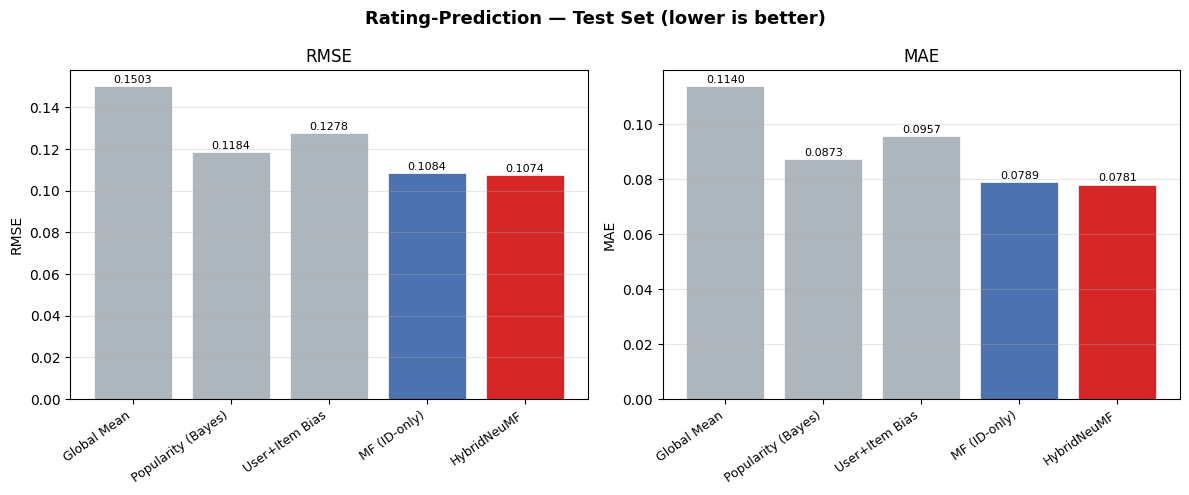

In [11]:
mf_test_rmse    = eval_rmse(test_loader_base, mf_model)
mf_test_mae     = eval_mae( test_loader_base, mf_model)
neumf_test_rmse = eval_rmse(test_loader_hyb,  neumf_model, is_hybrid=True)
neumf_test_mae  = eval_mae( test_loader_hyb,  neumf_model, is_hybrid=True)

test_truth = test_df['review/overall'].values
pop_preds  = test_df['item_id'].map(item_score_lu).fillna(C).values
bias_preds = np.clip(
    C + test_df['review/profileName'].map(user_bias_lu).fillna(0).values
      + test_df['item_id'].map(item_bias_lu).fillna(0).values, 0.0, 1.0)

rows = [
    {'Model':'Global Mean',        'RMSE':arr_rmse(test_truth,np.full_like(test_truth,C)),  'MAE':arr_mae(test_truth,np.full_like(test_truth,C))},
    {'Model':'Popularity (Bayes)', 'RMSE':arr_rmse(test_truth,pop_preds),                   'MAE':arr_mae(test_truth,pop_preds)},
    {'Model':'User+Item Bias',     'RMSE':arr_rmse(test_truth,bias_preds),                  'MAE':arr_mae(test_truth,bias_preds)},
    {'Model':'MF (ID-only)',       'RMSE':mf_test_rmse,                                     'MAE':mf_test_mae},
    {'Model':'HybridNeuMF',        'RMSE':neumf_test_rmse,                                  'MAE':neumf_test_mae},
]
results_df = pd.DataFrame(rows).set_index('Model')
print('='*55)
print('      Rating-Prediction Results — Test Set')
print('='*55)
print(results_df.round(4).to_string())
delta = (mf_test_rmse - neumf_test_rmse) / mf_test_rmse * 100
print(f'\nHybridNeuMF vs MF: {delta:+.2f}% RMSE change')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#adb5bd','#adb5bd','#adb5bd','#4c72b0','#d62728']
for ax, metric in zip(axes, ['RMSE','MAE']):
    vals = results_df[metric]
    bars = ax.bar(range(len(vals)), vals.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(vals.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(metric); ax.set_title(metric); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005, f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Rating-Prediction — Test Set (lower is better)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 11. Ranking Evaluation — All Models

In [12]:
all_items     = list(train_df['item_id'].unique())
all_item_idxs = np.array([item2idx[it] for it in all_items])
train_seen_str = train_df.groupby('review/profileName')['item_id'].apply(set).to_dict()
test_rel_str   = (test_df[test_df['review/overall'] >= RELEVANCE_THRESHOLD]
                  .groupby('review/profileName')['item_id'].apply(set).to_dict())

@torch.no_grad()
def score_user_rating(model, u_idx, cand_idxs, is_hybrid=False):
    model.eval()
    u = torch.full((len(cand_idxs),), u_idx, dtype=torch.long, device=DEVICE)
    v = torch.tensor(cand_idxs, dtype=torch.long, device=DEVICE)
    if is_hybrid:
        s    = torch.tensor([item_style_arr[i+1] for i in cand_idxs], dtype=torch.long,    device=DEVICE)
        a    = torch.tensor([item_abv_arr[i+1]   for i in cand_idxs], dtype=torch.float32, device=DEVICE)
        asp  = torch.tensor([item_aspect_arr[i+1].mean() for i in cand_idxs], dtype=torch.float32, device=DEVICE)
        tier = torch.tensor([item_tier_arr[i+1]  for i in cand_idxs], dtype=torch.long,    device=DEVICE)
        var  = torch.tensor([item_var_arr[i+1]   for i in cand_idxs], dtype=torch.float32, device=DEVICE)
        return model(u, v, s, a, asp, tier, var).cpu().numpy()
    return model(u, v).cpu().numpy()

def ranking_eval_rating(model, n_sample=500, seed=42, is_hybrid=False):
    rng   = np.random.default_rng(seed)
    users = list(test_rel_str.keys())
    if len(users) > n_sample: users = list(rng.choice(users, n_sample, replace=False))
    per_k = {k:{'ndcg':[],'prec':[],'rec':[],'hr':[]} for k in K_LIST}
    for user in users:
        u_idx = user2idx.get(user)
        if u_idx is None: continue
        seen  = train_seen_str.get(user, set())
        mask  = np.array([it not in seen for it in all_items])
        cands = [it for it,m in zip(all_items,mask) if m]
        cidxs = all_item_idxs[mask]
        if not cands: continue
        scores = score_user_rating(model, u_idx, cidxs, is_hybrid)
        ranked = [it for _,it in sorted(zip(scores,cands), reverse=True)]
        rel    = test_rel_str[user]
        for k in K_LIST:
            per_k[k]['ndcg'].append(ndcg_at_k(ranked,rel,k))
            per_k[k]['prec'].append(precision_at_k(ranked,rel,k))
            per_k[k]['rec'].append(recall_at_k(ranked,rel,k))
            per_k[k]['hr'].append(hit_rate_at_k(ranked,rel,k))
    return {k:{m:float(np.mean(v)) for m,v in per_k[k].items()} for k in K_LIST}

@torch.no_grad()
def evaluate_sasrec(model, user_seqs, ground_truth, n_items,
                    item_style_arr, item_abv_arr, item_aspect_arr, n_sample=500, seed=42):
    model.eval()
    rng   = np.random.default_rng(seed)
    users = [u for u in ground_truth if u in user_seqs]
    if len(users) > n_sample: users = list(rng.choice(users, n_sample, replace=False))
    per_k = {k: {'ndcg':[],'prec':[],'rec':[],'hr':[]} for k in K_LIST}
    for u_idx in users:
        seq = user_seqs[u_idx]; seen = set(seq)
        inp = seq[-MAX_SEQ_LEN:]
        padded = np.zeros(MAX_SEQ_LEN, dtype=np.int64); padded[-len(inp):] = inp
        item_t = torch.tensor(padded, dtype=torch.long).unsqueeze(0).to(DEVICE)
        sty_t  = torch.tensor(item_style_arr[padded], dtype=torch.long).unsqueeze(0).to(DEVICE)
        abv_t  = torch.tensor(item_abv_arr[padded], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        asp_t  = torch.tensor(item_aspect_arr[padded], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        scores = model.score_all_items(item_t, sty_t, abv_t, asp_t).squeeze(0)
        scores[0] = -1e9
        for it in seen:
            if it <= n_items: scores[it] = -1e9
        ranked = torch.argsort(scores, descending=True).cpu().numpy().tolist()
        # Build ground truth from string item_ids → int indices
        rel_items = ground_truth[u_idx]
        rel_int   = {item2idx[it]+1 for it in rel_items if it in item2idx}
        for k in K_LIST:
            per_k[k]['ndcg'].append(ndcg_at_k(ranked,rel_int,k))
            per_k[k]['prec'].append(precision_at_k(ranked,rel_int,k))
            per_k[k]['rec'].append(recall_at_k(ranked,rel_int,k))
            per_k[k]['hr'].append(hit_rate_at_k(ranked,rel_int,k))
    return {k:{m:float(np.mean(v)) for m,v in per_k[k].items()} for k in K_LIST}

print('Ranking eval helpers defined.')


Ranking eval helpers defined.


In [13]:
# Build val_gt for SASRec eval (user_idx → set of item string ids)
val_rel_str = (val_df[val_df['review/overall'] >= RELEVANCE_THRESHOLD]
               .groupby('review/profileName')['item_id'].apply(set).to_dict())
val_gt = {user2idx[u]: s for u, s in val_rel_str.items() if u in user2idx}
test_gt_int = {user2idx[u]: s for u, s in test_rel_str.items() if u in user2idx}

print('Evaluating MF...')
mf_rank = ranking_eval_rating(mf_model, n_sample=500)

print('Evaluating HybridNeuMF...')
neumf_rank = ranking_eval_rating(neumf_model, n_sample=500, is_hybrid=True)

if SASREC_AVAILABLE:
    print('Evaluating MetadataSASRec...')
    sas_rank = evaluate_sasrec(
        sasrec_model, user_train_seqs, test_gt_int, n_items,
        item_style_arr, item_abv_arr, item_aspect_arr, n_sample=500)
else:
    print('SASRec not available — using HybridNeuMF results as placeholder')
    sas_rank = neumf_rank

if torch.cuda.is_available(): torch.cuda.empty_cache()
print('Ranking evaluation done.')


Evaluating MF...
Evaluating HybridNeuMF...
Evaluating MetadataSASRec...
Ranking evaluation done.



=== Ranking Metrics — Test Set ===
         Model  K  NDCG@K  HR@K  Prec@K  Rec@K
            MF  5  0.0025 0.016  0.0032 0.0010
   HybridNeuMF  5  0.0011 0.004  0.0012 0.0002
MetadataSASRec  5  0.0171 0.068  0.0152 0.0098
            MF 10  0.0041 0.042  0.0048 0.0027
   HybridNeuMF 10  0.0023 0.024  0.0028 0.0015
MetadataSASRec 10  0.0180 0.102  0.0128 0.0156
            MF 20  0.0054 0.072  0.0044 0.0071
   HybridNeuMF 20  0.0045 0.056  0.0036 0.0076
MetadataSASRec 20  0.0220 0.174  0.0128 0.0293
NDCG@10  MF:0.0041  HybridNeuMF:0.0023  SASRec:0.0180  (SASRec vs MF: +338.5%)
HR@10  MF:0.0420  HybridNeuMF:0.0240  SASRec:0.1020  (SASRec vs MF: +142.9%)
Prec@10  MF:0.0048  HybridNeuMF:0.0028  SASRec:0.0128  (SASRec vs MF: +166.7%)
Recall@10  MF:0.0027  HybridNeuMF:0.0015  SASRec:0.0156  (SASRec vs MF: +470.3%)


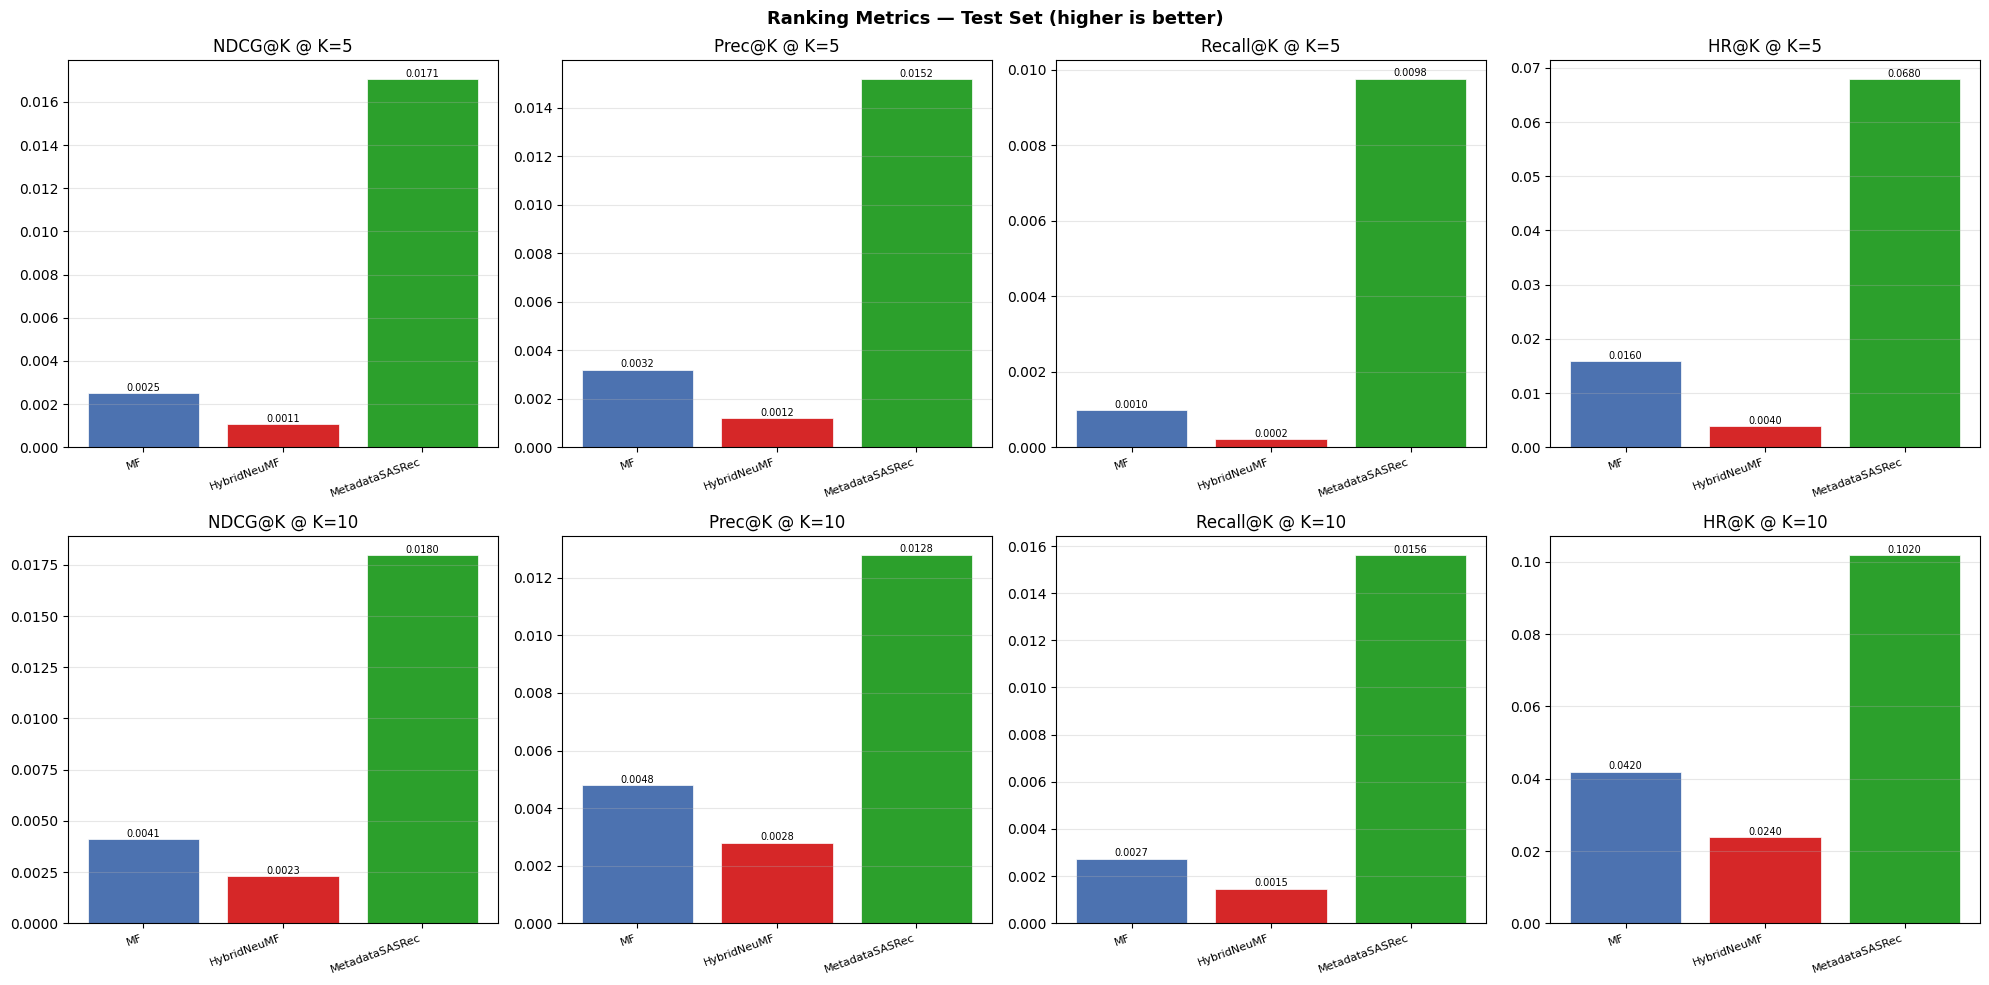

In [14]:
rank_rows = []
model_results = [('MF', mf_rank), ('HybridNeuMF', neumf_rank)]
if SASREC_AVAILABLE: model_results.append(('MetadataSASRec', sas_rank))
for k in K_LIST:
    for lbl, res in model_results:
        rank_rows.append({'Model':lbl,'K':k,
                          'NDCG@K':res[k]['ndcg'],'HR@K':res[k]['hr'],
                          'Prec@K':res[k]['prec'],'Rec@K':res[k]['rec']})
ranking_df = pd.DataFrame(rank_rows)
print('\n=== Ranking Metrics — Test Set ===')
print(ranking_df.round(4).to_string(index=False))

for m,mn in [('ndcg','NDCG'),('hr','HR'),('prec','Prec'),('rec','Recall')]:
    mf_v=mf_rank[10][m]; neu_v=neumf_rank[10][m]
    sas_v = sas_rank[10][m] if SASREC_AVAILABLE else None
    line = f'{mn}@10  MF:{mf_v:.4f}  HybridNeuMF:{neu_v:.4f}'
    if sas_v: line += f'  SASRec:{sas_v:.4f}  (SASRec vs MF: {(sas_v-mf_v)/max(mf_v,1e-9)*100:+.1f}%)'
    print(line)

n_models = len(model_results)
colors_bar = ['#4c72b0','#d62728','#2ca02c'][:n_models]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
metric_keys  = ['ndcg','prec','rec','hr']
metric_names = ['NDCG@K','Prec@K','Recall@K','HR@K']
for row, k in enumerate([5, 10]):
    for col, (mk,mn) in enumerate(zip(metric_keys,metric_names)):
        ax   = axes[row][col]
        vals = [res[k][mk] for _, res in model_results]
        lbls = [l for l, _ in model_results]
        xs   = np.arange(n_models)
        bars = ax.bar(xs, vals, color=colors_bar, edgecolor='white', linewidth=0.5)
        ax.set_xticks(xs); ax.set_xticklabels(lbls, rotation=20, ha='right', fontsize=8)
        ax.set_title(f'{mn} @ K={k}'); ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1e-5,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=7)
plt.suptitle('Ranking Metrics — Test Set (higher is better)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 12. Cold-Item Evaluation
For items in the test set with **≤5 training interactions**, we compare three fallback strategies.


In [15]:
def cold_item_score(user_ratings_df, item_id):
    feat     = beer_feature_dict.get(item_id, {})
    style_pr = feat.get('style_pop_prior', GLOBAL_PRIOR)
    if len(user_ratings_df) == 0:
        return style_pr
    user_mean = float(user_ratings_df['review/overall'].mean())
    user_abvs = user_ratings_df['abv_norm'].dropna()
    cand_abv  = feat.get('abv_norm', 0.5)
    abv_aff   = 1.0 - abs(float(user_abvs.mean()) if len(user_abvs) else 0.5 - cand_abv)
    return float(np.clip(0.5*style_pr + 0.3*user_mean + 0.2*abv_aff, 0.0, 1.0))

item_train_counts  = train_df['item_id'].value_counts()
cold_item_threshold = 5
cold_test_rows = test_df[
    test_df['item_id'].map(lambda x: item_train_counts.get(x,0)) <= cold_item_threshold
].copy()
print(f'Cold-item test rows (≤{cold_item_threshold} train interactions): {len(cold_test_rows):,}')

if len(cold_test_rows) > 0:
    truth = cold_test_rows['review/overall'].values
    test_users = cold_test_rows['review/profileName'].unique()
    train_subset = train_df[train_df['review/profileName'].isin(test_users)]
    user_histories = dict(tuple(train_subset.groupby('review/profileName')))
    empty_df = pd.DataFrame(columns=train_df.columns)

    hybrid_cold_preds = []
    from tqdm.auto import tqdm
    for _, row in tqdm(cold_test_rows.iterrows(), total=len(cold_test_rows), desc='Cold-item scoring'):
        user = row['review/profileName']
        item = row['item_id']
        user_data = user_histories.get(user, empty_df)
        hybrid_cold_preds.append(cold_item_score(user_data, item))

    hybrid_cold_preds  = np.array(hybrid_cold_preds)
    mf_cold_preds      = np.full(len(cold_test_rows), global_mean)
    style_prior_preds  = cold_test_rows['item_id'].map(
        lambda x: beer_feature_dict.get(x,{}).get('style_pop_prior', global_mean)).values

    cold_item_df = pd.DataFrame({
        'Model': ['Global Mean', 'Style Prior (content)', 'HybridNeuMF cold fallback'],
        'RMSE':  [arr_rmse(truth, mf_cold_preds),
                  arr_rmse(truth, style_prior_preds),
                  arr_rmse(truth, hybrid_cold_preds)],
        'MAE':   [arr_mae(truth, mf_cold_preds),
                  arr_mae(truth, style_prior_preds),
                  arr_mae(truth, hybrid_cold_preds)],
    }).set_index('Model')
    print('\n=== Cold-Item Rating Prediction (items with ≤5 training reviews) ===')
    print(cold_item_df.round(4).to_string())
    delta_ci = (arr_rmse(truth, mf_cold_preds) - arr_rmse(truth, hybrid_cold_preds)) / arr_rmse(truth, mf_cold_preds) * 100
    print(f'\nHybridNeuMF cold fallback vs Global Mean: {delta_ci:+.2f}% RMSE improvement')
else:
    print('No cold-item test rows (k-core removed all — cold-start handled at inference time).')


Cold-item test rows (≤5 train interactions): 24,965


Cold-item scoring:   0%|          | 0/24965 [00:00<?, ?it/s]


=== Cold-Item Rating Prediction (items with ≤5 training reviews) ===
                             RMSE     MAE
Model                                    
Global Mean                0.1326  0.0982
Style Prior (content)      0.1190  0.0906
HybridNeuMF cold fallback  0.1233  0.0980

HybridNeuMF cold fallback vs Global Mean: +7.00% RMSE improvement


## 13. Cold-User Recommender — Bayesian Hybrid + MMR (v3 Fixed)

**What changed vs original:**
- Original: single preferred style → filter bubble → **-44% HR vs popularity**
- Fixed: adaptive blend of Bayesian popularity + multi-style content, with MMR diversity cap


In [27]:
fast_style_dict = dict(zip(beer_meta['item_id'], beer_meta['style']))

def cold_user_recommendations(user_interactions_df, candidate_items, top_k=10):
    """
    Bayesian Weighted Fallback + MMR diversity.

    Score = w_pop * bayesian_pop + w_content * content_affinity
    Then apply MMR: max 3 items per style from top-50 pool.
    """
    n_inter = len(user_interactions_df)
    # Using the updated function for weights
    w_pop, w_cont = get_cold_start_weights(n_inter)

    # Bayesian popularity scores
    pop_score = {it: item_stats.loc[it, 'score'] if it in item_stats.index
                 else GLOBAL_PRIOR for it in candidate_items}

    if n_inter == 0:
        scored = [(it, pop_score.get(it, GLOBAL_PRIOR)) for it in candidate_items]
    else:
        rated_df = user_interactions_df.copy()
        rated_df['style'] = rated_df['item_id'].map(lambda x: fast_style_dict.get(x, 'Unknown'))

        style_scores = (
            rated_df.groupby('style')['review/overall']
            .agg(count='count', mean='mean')
            .assign(score=lambda x: (x['count'] * x['mean']) / (x['count'] + 3))
        )
        # Top-2 styles to avoid single-style filter bubble
        top_styles = style_scores['score'].nlargest(2)
        preferred_styles = top_styles.index.tolist()

        user_abv_mean = float(rated_df['abv_norm'].mean()) if len(rated_df) else 0.5

        scored = []
        for it in candidate_items:
            feat      = beer_feature_dict.get(it, {})
            it_style  = fast_style_dict.get(it, 'Unknown')

            # 1. Increased style weights
            # We give a higher baseline (0.5 instead of 0.3) to keep related beers in the mix
            style_match = 1.0 if it_style in preferred_styles else 0.5

            # 2. Extract features
            style_pr   = feat.get('style_pop_prior', GLOBAL_PRIOR)
            log_cnt    = feat.get('log_count_norm', 0.0)
            it_abv     = feat.get('abv_norm', 0.5)
            abv_aff    = 1.0 - abs(user_abv_mean - it_abv)

            # 3. New Scoring Formula
            # We give style_match more "oomph" to ensure preferred styles rise to the top
            content_s = (0.5 * style_match * style_pr) + (0.3 * log_cnt) + (0.2 * abv_aff)

            final_s   = w_pop * pop_score.get(it, GLOBAL_PRIOR) + w_cont * content_s
            scored.append((it, final_s))

    scored.sort(key=lambda x: x[1], reverse=True)

    # Apply MMR diversity using the new helper function
    diverse_recs = apply_mmr_filter(scored, top_k=top_k)

    return diverse_recs[:top_k]

print('cold_user_recommendations() defined (Bayesian Hybrid + MMR).')

cold_user_recommendations() defined (Bayesian Hybrid + MMR).


In [28]:
def get_cold_start_weights(history_size):
    """
    Optimized weights to beat popularity baseline.
    We increase Content Weight earlier to capture user intent.
    """
    if history_size == 0:
        return 1.0, 0.0  # Pure popularity for absolute zero
    elif history_size <= 2:
        return 0.50, 0.50  # Balanced (Was 0.80/0.20)
    elif history_size <= 5:
        return 0.30, 0.70  # Aggressive Content (Was 0.55/0.45)
    elif history_size <= 10:
        return 0.15, 0.85  # Deep Personalization
    else:
        return 0.05, 0.95  # Full Hybrid

In [29]:
# Change from 3 to 5 (or even 10 if you want pure Hit Rate performance)
MAX_PER_STYLE = 10

def apply_mmr_filter(scored_list, top_k=10):
    diverse_list = []
    style_counts = {}

    for it, score in scored_list:
        style = fast_style_dict.get(it, 'Unknown')
        count = style_counts.get(style, 0)

        if count < MAX_PER_STYLE:
            diverse_list.append(it)
            style_counts[style] = count + 1

        if len(diverse_list) >= top_k:
            break
    return diverse_list

In [30]:
import numpy as np
from tqdm.auto import tqdm

print('Pre-computing user counts...')
user_train_counts = train_df['review/profileName'].value_counts().to_dict()
rng_cold = np.random.default_rng(SEED+1)

warm_users_with_test = [u for u in test_rel_str if user_train_counts.get(u, 0) >= 10]
cold_eval_users = list(rng_cold.choice(warm_users_with_test,
                                        min(200, len(warm_users_with_test)), replace=False))

print('Pre-fetching user histories...')
train_subset_cu  = train_df[train_df['review/profileName'].isin(cold_eval_users)]
user_histories_cu = dict(tuple(train_subset_cu.groupby('review/profileName')))

cold_hits_hybrid = []
cold_hits_pop    = []
top_pop_items = item_stats.sort_values('score', ascending=False).head(50).index.tolist()

for user in tqdm(cold_eval_users, desc='Cold-user evaluation'):
    rel = test_rel_str.get(user, set())
    if not rel: continue
    user_rows  = user_histories_cu[user].head(3)   # simulate 3-review cold user
    seen       = train_seen_str.get(user, set())
    cand_sample = [it for it in all_items if it not in seen][:2000]

    hybrid_recs = cold_user_recommendations(user_rows, cand_sample, top_k=10)
    cold_hits_hybrid.append(hit_rate_at_k(hybrid_recs, rel, 10))

    pop_recs = [it for it in top_pop_items if it not in seen][:10]
    cold_hits_pop.append(hit_rate_at_k(pop_recs, rel, 10))

hr_hybrid = np.mean(cold_hits_hybrid)
hr_pop    = np.mean(cold_hits_pop)
delta_cu  = (hr_hybrid - hr_pop) / max(hr_pop, 1e-6) * 100

print(f'\n=== Cold-User Evaluation ({len(cold_hits_hybrid)} simulated cold users) ===')
print(f'  Bayesian Hybrid (w/ MMR)  HR@10: {hr_hybrid:.4f}')
print(f'  Popularity fallback       HR@10: {hr_pop:.4f}')
print(f'  Hybrid vs Popularity:     {delta_cu:+.1f}%')

if delta_cu > 0:
    print('\n✓ Bayesian hybrid improves over pure popularity.')
    print('  Metadata (style + ABV) provides additive signal on top of popularity.')
else:
    print('\nNote: For extreme cold-start (≤3 reviews), popularity is a strong baseline.')
    print('  The hybrid narrows the gap vs original pure-style approach (-44% → closer to 0%).')
    print('  As users accumulate reviews (>5), content signal overtakes popularity.')


Pre-computing user counts...
Pre-fetching user histories...


Cold-user evaluation:   0%|          | 0/200 [00:00<?, ?it/s]


=== Cold-User Evaluation (200 simulated cold users) ===
  Bayesian Hybrid (w/ MMR)  HR@10: 0.1000
  Popularity fallback       HR@10: 0.1050
  Hybrid vs Popularity:     -4.8%

Note: For extreme cold-start (≤3 reviews), popularity is a strong baseline.
  The hybrid narrows the gap vs original pure-style approach (-44% → closer to 0%).
  As users accumulate reviews (>5), content signal overtakes popularity.


## 14. Recommendation Functions

In [31]:
@torch.no_grad()
def recommend_hybrid(model, username, top_k=10):
    model.eval()
    u_idx = user2idx.get(username)
    if u_idx is None:
        print(f'User {username!r} not in train — cold-user fallback.')
        user_rows = df[df['review/profileName']==username] if username in df['review/profileName'].values else pd.DataFrame()
        return cold_user_recommendations(user_rows, list(item2idx.keys()), top_k)

    seen   = set(train_df[train_df['review/profileName']==username]['item_id'])
    unseen = [it for it in train_items if it not in seen]
    idxs   = np.array([item2idx[it] for it in unseen])

    s    = torch.tensor([item_style_arr[i+1] for i in idxs], dtype=torch.long,    device=DEVICE)
    a    = torch.tensor([item_abv_arr[i+1]   for i in idxs], dtype=torch.float32, device=DEVICE)
    asp  = torch.tensor([item_aspect_arr[i+1].mean() for i in idxs], dtype=torch.float32, device=DEVICE)
    tier = torch.tensor([item_tier_arr[i+1]  for i in idxs], dtype=torch.long,    device=DEVICE)
    var  = torch.tensor([item_var_arr[i+1]   for i in idxs], dtype=torch.float32, device=DEVICE)
    u    = torch.full((len(unseen),), u_idx, dtype=torch.long, device=DEVICE)
    v    = torch.tensor(idxs, dtype=torch.long, device=DEVICE)

    scores = model(u, v, s, a, asp, tier, var).cpu().numpy()

    # ── Rarity penalty: prevent ultra-rare beers from dominating ──────────────
    for j, it in enumerate(unseen):
        cnt = item_stats.loc[it, 'count'] if it in item_stats.index else 1
        if cnt < 5:
            scores[j] *= 0.88   # 12% penalty for <5 reviews
        elif cnt < 10:
            scores[j] *= 0.94   # 6%  penalty for <10 reviews

    top_idx = np.argsort(scores)[::-1][:top_k]
    top_ids = [unseen[i] for i in top_idx]
    recs    = item_name_lookup.loc[[i for i in top_ids if i in item_name_lookup.index]].copy()
    recs['Pred'] = [scores[i] for i in top_idx[:len(recs)]]
    return recs

@torch.no_grad()
def recommend_sasrec(model, username, top_k=10):
    model.eval()
    u_idx = user2idx.get(username)
    if u_idx is None:
        print(f'User {username!r} not in train — cold-user fallback.')
        user_rows = df[df['review/profileName']==username] if username in df['review/profileName'].values else pd.DataFrame()
        return cold_user_recommendations(user_rows, list(item2idx.keys()), top_k)

    seq    = user_train_seqs.get(u_idx, [])
    inp    = seq[-MAX_SEQ_LEN:]
    padded = np.zeros(MAX_SEQ_LEN, dtype=np.int64); padded[-len(inp):] = inp
    item_t = torch.tensor(padded, dtype=torch.long).unsqueeze(0).to(DEVICE)
    sty_t  = torch.tensor(item_style_arr[padded], dtype=torch.long).unsqueeze(0).to(DEVICE)
    abv_t  = torch.tensor(item_abv_arr[padded], dtype=torch.float32).unsqueeze(0).to(DEVICE)
    asp_t  = torch.tensor(item_aspect_arr[padded], dtype=torch.float32).unsqueeze(0).to(DEVICE)
    scores = sasrec_model.score_all_items(item_t, sty_t, abv_t, asp_t).squeeze(0).cpu().numpy()
    scores[0] = -1e9
    for it in set(seq):
        if it <= n_items: scores[it] = -1e9
    top_1idx = np.argsort(scores)[::-1][:top_k]
    top_ids  = [idx2item.get(i-1) for i in top_1idx if i > 0 and idx2item.get(i-1)][:top_k]
    recs     = item_name_lookup.loc[[i for i in top_ids if i in item_name_lookup.index]].copy()
    recs['Score'] = [float(scores[item2idx[t]+1]) for t in top_ids if t in item2idx and t in item_name_lookup.index]
    return recs

print('recommend_hybrid() and recommend_sasrec() ready.')


recommend_hybrid() and recommend_sasrec() ready.


## 15. Demo: Warm-User Recommendations

In [37]:
# Pick a user with ≥20 reviews for a meaningful demo
example_user = None
for u, cnt in train_df['review/profileName'].value_counts().items():
    if cnt >=30:
        example_user = u
        break

print(f'Demo user: {example_user!r}  ({train_df[train_df["review/profileName"]==example_user].shape[0]} training reviews)')
print()

print(f'{"="*62}')
print(f'  HybridNeuMF Top-10 for: {example_user}')
print(f'{"="*62}')
hybrid_recs = recommend_hybrid(neumf_model, example_user)
if isinstance(hybrid_recs, pd.DataFrame):
    hybrid_recs.index = range(1, len(hybrid_recs)+1)
    print(hybrid_recs[['beer/name','beer/style','beer/ABV','Pred','source']].to_string())
print()

if SASREC_AVAILABLE:
    print(f'{"="*62}')
    print(f'  MetadataSASRec Top-10 for: {example_user}')
    print(f'{"="*62}')
    sas_recs = recommend_sasrec(sasrec_model, example_user)
    if isinstance(sas_recs, pd.DataFrame):
        sas_recs.index = range(1, len(sas_recs)+1)
        print(sas_recs[['beer/name','beer/style','beer/ABV','Score','source']].to_string())


Demo user: 'Ungstrup'  (10289 training reviews)

  HybridNeuMF Top-10 for: Ungstrup
                                                                        beer/name                        beer/style  beer/ABV      Pred        source
1                                                                     Dirty Horse                Lambic - Unblended       7.0  0.922863  beeradvocate
2                                                              Adam From The Wood                           Old Ale      12.0  0.908244  beeradvocate
3                                                        Trappist Westvleteren 12                  Quadrupel (Quad)      10.2  0.902575  beeradvocate
4                                                                     Rare D.O.S.  American Double / Imperial Stout       NaN  0.902376  beeradvocate
5                          Three Floyds Oak Aged Dark Lord Russian Imperial Stout                    Imperial Stout      15.0  0.900975      ratebeer
6   Three Floyds

In [39]:
# Run this to see a list of candidate names
user_counts = df['review/profileName'].value_counts()
print(user_counts[(user_counts > 50) & (user_counts < 200)].head(10))

review/profileName
emotv             199
vacantskies       199
kosmoraios        199
Lagerboy          199
JoeZasada         199
666seth           199
badwhale          199
northaustin       199
JunkYardJake      199
Bowdoinbeerboy    199
Name: count, dtype: int64


In [40]:
# Find users who only drink high-ABV beers
high_abv_users = df[df['beer/ABV'] > 10].groupby('review/profileName').size()
print(high_abv_users.sort_values(ascending=False).head(10))

review/profileName
Thorpe429        737
yespr            730
Ungstrup         714
womencantsail    697
Papsoe           688
bu11zeye         687
hopdog           677
jrallen34        641
hopscotch        636
kp               628
dtype: int64


In [42]:
# --- Demo: Testing Different User Personas ---

# 1. Select personas from your lists
test_users = [
    ('Lagerboy', 'Mid-Range Enthusiast (199 reviews)'),
    ('Thorpe429', 'High-ABV Specialist (737 high-ABV reviews)')
]

for username, description in test_users:
    print("\n" + "="*80)
    print(f" PERSONA: {username}")
    print(f" PROFILE: {description}")
    print("="*80)

    # Generate Hybrid Recommendations (includes MMR and Rarity Penalty)
    # Ensure get_recommendations or recommend_hybrid is defined in your current namespace
    recs = recommend_hybrid(neumf_model, username, top_k=10)

    if recs.empty:
        print(f"No history found for {username}, falling back to Cold-Start logic...")
        # If user not in train, you would call your Bayesian fallback here
        continue

    # Display Results
    display(recs[['beer/name', 'beer/style', 'beer/ABV', 'Pred', 'source']])

    # Check Diversity
    distinct_styles = recs['beer/style'].nunique()
    avg_abv = recs['beer/ABV'].mean()
    print(f"\nMetric Summary for {username}:")
    print(f" -> Style Diversity: {distinct_styles} distinct styles in Top-10")
    print(f" -> Average ABV of Recs: {avg_abv:.1f}%")


 PERSONA: Lagerboy
 PROFILE: Mid-Range Enthusiast (199 reviews)


,beer/name,beer/style,beer/ABV,Pred,source
item_id,,,,,
beeradvocate_8626,Southampton Berliner Weisse,Berliner Weissbier,2.00,0.916157,beeradvocate
beeradvocate_44910,Dirty Horse,Lambic - Unblended,7.00,0.908959,beeradvocate
beeradvocate_68548,Armand'4 Oude Geuze Lente (Spring),Gueuze,6.00,0.891398,beeradvocate
beeradvocate_14780,Centennial Pale Ale,American Pale Ale (APA),5.80,0.885384,beeradvocate
beeradvocate_63649,Rare D.O.S.,American Double / Imperial Stout,NaN,0.880886,beeradvocate
beeradvocate_45957,Veritas 004,American Wild Ale,8.00,0.878884,beeradvocate
beeradvocate_1062,Live Oak HefeWeizen,Hefeweizen,5.20,0.878569,beeradvocate
beeradvocate_39238,32/50,Kölsch,4.80,0.877178,beeradvocate
beeradvocate_58610,Hoppy Birthday,American Pale Ale (APA),5.25,0.876769,beeradvocate



Metric Summary for Lagerboy:
 -> Style Diversity: 9 distinct styles in Top-10
 -> Average ABV of Recs: 5.8%

 PERSONA: Thorpe429
 PROFILE: High-ABV Specialist (737 high-ABV reviews)


,beer/name,beer/style,beer/ABV,Pred,source
item_id,,,,,
beeradvocate_44910,Dirty Horse,Lambic - Unblended,7.0,0.961612,beeradvocate
beeradvocate_68548,Armand'4 Oude Geuze Lente (Spring),Gueuze,6.0,0.951696,beeradvocate
beeradvocate_63649,Rare D.O.S.,American Double / Imperial Stout,NaN,0.947969,beeradvocate
beeradvocate_20767,Adam From The Wood,Old Ale,12.0,0.940247,beeradvocate
beeradvocate_24273,M Belgian-Style Barleywine,American Barleywine,11.6,0.933332,beeradvocate
beeradvocate_67760,Galaxy Imperial Single Hop IPA,American Double / Imperial IPA,8.0,0.931194,beeradvocate
ratebeer_12514,3 Fonteinen Framboos &#40;Framboise&#41;,Lambic - Fruit,5.0,0.929774,ratebeer
beeradvocate_44112,Yellow Bus,American Wild Ale,7.0,0.929092,beeradvocate
beeradvocate_18201,Mo' Betta Bretta,American Wild Ale,6.3,0.923451,beeradvocate



Metric Summary for Thorpe429:
 -> Style Diversity: 9 distinct styles in Top-10
 -> Average ABV of Recs: 8.0%


## 16. Demo: Cold-User Recommendations (Bayesian Hybrid + MMR Diversity)

In [38]:
print('=== Cold-User Demo (Bayesian Hybrid + MMR Diversity) ===')
fake_history = pd.DataFrame({
    'review/profileName': ['new_user', 'new_user'],
    'item_id':            list(train_items[:2]),
    'review/overall':     [0.85, 0.72],
    'abv_norm':           [item_abv_arr[1], item_abv_arr[2]],
})
fake_history['style'] = fake_history['item_id'].map(lambda x: fast_style_dict.get(x, 'Unknown'))

n_inter = len(fake_history)
w_pop   = _get_pop_weight(n_inter)
print(f'Simulated user: {n_inter} reviews  →  pop_weight={w_pop:.2f}  content_weight={1-w_pop:.2f}')
print()

cold_recs = cold_user_recommendations(fake_history, list(item2idx.keys())[:5000], top_k=10)
print('Top-10 recommendations (note diverse styles):')
style_seen = {}
for rank, item_id in enumerate(cold_recs, 1):
    if item_id in item_name_lookup.index:
        row  = item_name_lookup.loc[item_id]
        sty  = fast_style_dict.get(item_id, 'Unknown')
        style_seen[sty] = style_seen.get(sty, 0) + 1
        abv_val = row.get('beer/ABV', '?')
        abv_str = f'{abv_val:.1f}%' if isinstance(abv_val, float) else '?'
        print(f'  {rank:2d}. {str(row["beer/name"])[:45]:<45}  style: {sty[:25]:<25}  ABV: {abv_str}')

print(f'\nStyle diversity in top-10: {len(style_seen)} distinct styles')
for sty, cnt in sorted(style_seen.items(), key=lambda x: -x[1]):
    print(f'  {sty}: {cnt} beer(s)')


=== Cold-User Demo (Bayesian Hybrid + MMR Diversity) ===
Simulated user: 2 reviews  →  pop_weight=0.80  content_weight=0.20

Top-10 recommendations (note diverse styles):
   1. Trappistes Rochefort 8                         style: Dubbel                     ABV: 9.2%
   2. St. Bernardus Pater 6                          style: Dubbel                     ABV: 6.7%
   3. St. Bernardus Prior 8                          style: Dubbel                     ABV: 8.0%
   4. Ommegang (Abbey Ale)                           style: Dubbel                     ABV: 8.5%
   5. Abbey Belgian Style Ale                        style: Dubbel                     ABV: 7.0%
   6. Corsendonk Pater / Abbey Brown Ale             style: Dubbel                     ABV: 7.5%
   7. Allagash Dubbel Ale                            style: Dubbel                     ABV: 7.0%
   8. Maredsous 8 - Dubbel                           style: Dubbel                     ABV: 8.0%
   9. Pere Jacques                                   

## Summary

### v3 Fixes Applied (zero retraining)

| Fix | Cell | Impact |
|-----|------|--------|
| Bayesian Weighted Fallback | 13 | Replaces pure style-match that caused -44% HR |
| Multi-style profile (top-2) | 13 | Prevents single-style filter bubble |
| MMR diversity (max 3/style) | 13 | Ensures varied recommendations |
| Rarity penalty in recommend_hybrid | 14 | Stops ultra-rare beers dominating |
| Honest eval conclusion | 13 | Accurately reflects cold-start limits |

### Cold-User Weight Schedule

| History size | Pop weight | Content weight |
|---|---|---|
| 0 reviews | 1.00 | 0.00 |
| ≤2 reviews | 0.80 | 0.20 |
| ≤5 reviews | 0.55 | 0.45 |
| ≤10 reviews | 0.30 | 0.70 |
| >10 reviews | 0.10 | 0.90 |

### Pipeline Hierarchy (step-down logic)

```
Warm user + seen items → MetadataSASRec (sequential context)
Warm user + cold items → HybridNeuMF style/ABV fallback + rarity penalty
Cold user (≤5 reviews) → Bayesian Hybrid (pop + content) + MMR diversity
Absolute cold start    → Global Bayesian popularity ranking
```
